# CMIP7 sea ice data availability and loading

This notebook checks which CMIP7 sea ice variables have been published on ESGF, and by which models and experiments, then loads one variable as an example.

1. **Setup**: install and import packages, including the loaders in `scripts/data_access/load_cmip.py`.
2. **Data availability**: search ESGF for each variable across all experiments (no data are downloaded) and build a variable × experiment table of the models that have published it.
3. **Loading example**: download monthly sea ice concentration for one model, plot concentration, the ocean mask, and cell areas.
4. **Clean up**: optionally delete the downloaded files from `/tmp`.

In [1]:
# Install these packages once per session on the cryohub.
# All packages are used by the loading code in scripts/data_access/load_cmip.py
# Skip if these packages are already installed in your environment

# ── Core climate/geospatial dependencies ──────────────────────────────────────
%pip install -q regionmask       # regional masking for geospatial data
%pip install -q bottleneck       # speeds up xarray reduce operations (rolling mean, etc.)
%pip install -q xesmf            # regridding for Earth System Model output
%pip install -q cf_xarray        # CF convention accessor for xarray datasets

# ── ESGF data access ──────────────────────────────────────────────────────────
%pip install -q intake-esgf      # intake driver for ESGF catalogs

# globus-sdk must stay below v4 until intake-esgf adds compatibility
%pip install -q "globus-sdk<4"

# pydantic upgrade needed for intake-esm compatibility
%pip install -q --upgrade intake-esm pydantic

# numpy pinned to <=2.3 due to numba incompatibility
%pip install -q "numpy<=2.3"

#colormaps
%pip install -q cmocean

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-ai 2.31.7 requires faiss-cpu!=1.8.0.post0,<2.0.0,>=1.8.0, which is not installed.
Note: you may need to restart the kernel to use upd

**Restart the kernel after the installs above before running any further cells.**

## Setup

Imports the plotting/analysis packages and this repo's code from `scripts/`. The first lines add the repository root to `sys.path` (`REPO_ROOT`), so the cell works as long as `pyproject.toml` is in the root.

In [1]:
import sys
from pathlib import Path

# make the repo's scripts/ importable
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
from scripts.data_access.load_cmip import CMIP7, clear_esgf_cache
from scripts.diagnostics.availability import cmip7_load_list, cmip7_availability_table
import time
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean as cm

Optionally reload `load_cmip` after editing it, without restarting the kernel.

In [2]:
#import importlib
#import scripts.data_access.load_cmip as load_cmip
#importlib.reload(load_cmip)

## Data availability (sea ice)
`variables` lists the variables to check. They are CMIP7 `variable_id`s, except that the CMIP6 hemispheric names (`siarean`, `sivoln`, ...) can also be used: they map to the CMIP7 variable with `region='nh'`/`'sh'` (e.g. `sivoln` → `sivol`, `nh`).

`fallback` gives a description (`'Long Name [units]'`) for variables that no model has published yet, so they still appear in the table. Every other variable gets its long name and units from ESGF.

In [3]:
variables = ['siconc',
             'siarean',
             'sithick',
             'sieqthick',
             'sivoln',
             'snd',
             'sifb',
             'sidmassmelttop',
             'sidmassmeltbot',
             'sidmassmeltlat',
             'sidmassgrowthbot',
             'sidmassgrowthwat',
             'sidmassgrowthsi',
             'evspsbl',
             'sidmassdyn',
             'snm',
             'prsn',
             'sisndmasssi',
             'sbl',
             'sisndmasswind',
             'sisndmassdyn']

# Descriptions ('Long Name [units]') for variables no model has published yet;
# everything else gets long_name/units from ESGF
fallback = {
    'sisndmasswind': 'Snow Mass Rate of Change Through Wind Drift of Snow [kg m-2 s-1]',
}

### Search ESGF

`CMIP7(...).data_summary()` searches ESGF for one variable. `experiment_id=None` covers every published experiment. It returns the search results as tables (one row per ESGF dataset) without downloading anything, so it is quick, but a full list of variables can still take a few minutes.

In [4]:
cat_esgf_cmip7 = {}

# experiment_id=None: one search per variable covering every published experiment
for var in variables:
    start = time.time()
    cat_esgf_cmip7[var] = CMIP7(grid_label='native', variable=var, realm='seaIce', frequency='mon', experiment_id=None).data_summary()
    elapsed = time.time() - start
    print(f"✅ {var} search completed in {elapsed:.2f} seconds\n")

✅ siconc search completed in 7.05 seconds

✅ siarean search completed in 2.32 seconds

✅ sithick search completed in 1.63 seconds

✅ sieqthick search completed in 1.30 seconds

✅ sivoln search completed in 1.06 seconds

✅ snd search completed in 1.61 seconds

✅ sifb search completed in 1.09 seconds

✅ sidmassmelttop search completed in 1.25 seconds

✅ sidmassmeltbot search completed in 1.26 seconds

✅ sidmassmeltlat search completed in 1.07 seconds

✅ sidmassgrowthbot search completed in 1.23 seconds

✅ sidmassgrowthwat search completed in 1.09 seconds

✅ sidmassgrowthsi search completed in 1.28 seconds

✅ evspsbl search completed in 1.22 seconds

✅ sidmassdyn search completed in 1.08 seconds

✅ snm search completed in 1.07 seconds

✅ prsn search completed in 1.09 seconds

✅ sisndmasssi search completed in 1.07 seconds

✅ sbl search completed in 1.07 seconds

✅ sisndmasswind search completed in 0.58 seconds

✅ sisndmassdyn search completed in 1.08 seconds



### Availability table

`cmip7_load_list` gives, for each variable, the models available in each experiment. `cmip7_availability_table` combines all variables into one table:
- rows are `(variable_id, region)` as published on ESGF;
- there is one column per experiment (historical, then scenarios from low to high forcing, then control/idealized runs);
- each cell lists the models, with their number of ensemble members, e.g. `CanESM6-0-MR (5)`.

Only native-grid data are counted. `counts=True` gives the number of models instead (`availability_count_cmip7_df`).

In [5]:
models_cmip7 = {var: cmip7_load_list(cat_esgf_cmip7[var]) for var in variables}

# rows = variables with data from at least one model (plus fallback ones), then long_name/units
# and one column per experiment_id
# number of ensemble members are shown in parentheses 
availability_cmip7_df = cmip7_availability_table(cat_esgf_cmip7, fallback=fallback)
availability_count_cmip7_df = cmip7_availability_table(cat_esgf_cmip7, fallback=fallback, counts=True)

In [6]:
availability_cmip7_df.style.set_properties(**{'white-space': 'normal'})

,,long_name,units,historical,esm-hist,scen7-vl,scen7-m,scen7-h,esm-scen7-vl,esm-scen7-m,esm-scen7-h,piControl,esm-piControl,1pctCO2,abrupt-4xCO2
variable_id,region,,,,,,,,,,,,,,
siconc,glb,Sea-Ice Area Percentage (Ocean Grid),%,"CanESM6-0-MR (25), UKCM2-0-LL (5)","CanESM5-1 (25), EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (23),CanESM6-0-MR (24),CanESM6-0-MR (25),UKESM1-3-LL (6),"CanESM5-1 (10), UKESM1-3-LL (1)","CanESM5-1 (25), UKESM1-3-LL (6)",CanESM5-1 (1),"CanESM5-1 (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKCM2-0-LL (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKESM1-3-LL (1)"
siarea,nh,Sea-Ice Area North,1e6 km2,,,CanESM6-0-MR (4),CanESM6-0-MR (5),CanESM6-0-MR (7),,,,,,,
sithick,glb,Sea-Ice Thickness,m,"CanESM6-0-MR (25), UKCM2-0-LL (5)","CanESM5-1 (25), EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (23),CanESM6-0-MR (25),CanESM6-0-MR (25),UKESM1-3-LL (6),"CanESM5-1 (10), UKESM1-3-LL (1)","CanESM5-1 (25), UKESM1-3-LL (6)",CanESM5-1 (1),"CanESM5-1 (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKCM2-0-LL (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKESM1-3-LL (1)"
sieqthick,glb,Sea-Ice Volume per Area,m,UKCM2-0-LL (5),"CanESM5-1 (5), EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (4),CanESM6-0-MR (5),CanESM6-0-MR (7),UKESM1-3-LL (6),UKESM1-3-LL (1),UKESM1-3-LL (6),,UKESM1-3-LL (1),"CanESM5-1 (1), UKCM2-0-LL (1), UKESM1-3-LL (1)","CanESM5-1 (1), UKESM1-3-LL (1)"
sivol,nh,Sea-Ice Volume North,1e3 km3,,EC-Earth3-ESM-1-1 (1),CanESM6-0-MR (4),CanESM6-0-MR (5),CanESM6-0-MR (7),,,,,,,
snd,glb,Snow Thickness,m,CanESM6-0-MR (25),"CanESM5-1 (25), EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (23),CanESM6-0-MR (25),CanESM6-0-MR (25),UKESM1-3-LL (6),"CanESM5-1 (10), UKESM1-3-LL (1)","CanESM5-1 (25), UKESM1-3-LL (6)",CanESM5-1 (1),"CanESM5-1 (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKESM1-3-LL (1)","CanESM5-1 (1), CanESM6-0-MR (1), UKESM1-3-LL (1)"
sifb,glb,Sea-Ice Freeboard,m,UKCM2-0-LL (5),"EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (1),CanESM6-0-MR (1),CanESM6-0-MR (1),UKESM1-3-LL (6),UKESM1-3-LL (1),UKESM1-3-LL (6),,UKESM1-3-LL (1),"UKCM2-0-LL (1), UKESM1-3-LL (1)",UKESM1-3-LL (1)
sidmassmelttop,glb,Sea-Ice Mass Change Through Surface Melting,kg m-2 s-1,UKCM2-0-LL (5),"CanESM5-1 (5), EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (4),CanESM6-0-MR (5),CanESM6-0-MR (7),UKESM1-3-LL (6),UKESM1-3-LL (1),UKESM1-3-LL (6),,UKESM1-3-LL (1),"CanESM5-1 (1), UKCM2-0-LL (1), UKESM1-3-LL (1)","CanESM5-1 (1), UKESM1-3-LL (1)"
sidmassmeltbot,glb,Sea-Ice Mass Change Through Bottom Melting,kg m-2 s-1,UKCM2-0-LL (5),"EC-Earth3-ESM-1-1 (1), UKESM1-3-LL (5)",CanESM6-0-MR (4),CanESM6-0-MR (5),CanESM6-0-MR (7),UKESM1-3-LL (6),UKESM1-3-LL (1),UKESM1-3-LL (6),,UKESM1-3-LL (1),"UKCM2-0-LL (1), UKESM1-3-LL (1)",UKESM1-3-LL (1)


Save the table to `results/summaries/`.

In [7]:
availability_cmip7_df.to_csv(REPO_ROOT / 'results' / 'summaries' / 'cmip7_availability.csv')

## Loading example

The next cell quiets the noisy Google Cloud and `urllib3` loggers. Other warnings (e.g. from `regrid`) still show.

In [8]:
# Quiet the noisy Google Cloud and urllib3 loggers
for name in logging.Logger.manager.loggerDict.keys():
    if ('google' in name) or ('url' in name):
        logger = logging.getLogger(name)
        logger.setLevel(logging.CRITICAL)
        logger.propagate = False  # Prevent propagation to root logger
        for handler in logger.handlers:  # Remove existing handlers
            logger.removeHandler(handler)

Load monthly sea ice concentration for CanESM6-0-MR, experiment `scen7-m`, on the model's native grid. `members='first'` loads one ensemble member; leave it out to load all of them. Files are downloaded from ESGF to `/tmp/esgf_manual` (see **Clean up**).

The result is an `xarray.Dataset` with dims `(experiment_id, member_id, time, y, x)`. `member_id` is `<source_id>_<variant_label>`. `areacello` (cell area, m$^2$) and `mask` (ocean percentage, sftof) are attached as coordinates; they are used for area-weighted sums and means and for regridding.

To regrid after loading, use `from scripts.preprocessing.regrid import regrid`, e.g. `regrid(CMIP7_siconc, grid_OSISAF_nh)`. Regrid one model at a time.

In [9]:
models = ['CanESM6-0-MR']
args = {'grid_label':'native', 'realm':'seaIce', 'frequency':'mon', 'experiment_id':'scen7-m', 'verbose':True}

In [10]:
CMIP7_siconc = CMIP7(**args, variable='siconc', source_id=models, members='first').load_data()

['siconc'] available from: ['CanESM6-0-MR']


  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 1
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r1i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r1i1p1f1_202201-210012.nc
[CanESM6-0-MR] load_from_catalog returned 1 dataset(s) for siconc (grid=g147):
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/areacello/ti-u-hxy-u/g147/v20260629/areacello_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/sftof/ti-u-hxy-u/g147/v20260629/sftof_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Concatenating 1 dataset(s), 1 member(s) total


In [11]:
CMIP7_siconc

<xarray.Dataset> Size: 455MB
Dimensions:        (experiment_id: 1, member_id: 1, y: 331, x: 360, time: 948)
Coordinates:
  * experiment_id  (experiment_id) <U7 28B 'scen7-m'
  * member_id      (member_id) <U21 84B 'CanESM6-0-MR_r1i1p1f1'
    grid_label     (member_id) <U4 16B 'g147'
    native_grid    (member_id) bool 1B True
  * y              (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x              (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
    lat            (y, x) float64 953kB -84.21 -84.21 -84.21 ... 50.23 50.01
    lon            (y, x) float64 953kB 73.5 74.5 75.5 ... 72.95 72.96 72.99
    areacello      (y, x) float32 477kB nan nan nan nan nan ... nan nan nan nan
    mask           (y, x) float32 477kB ...
  * time           (time) datetime64[ns] 8kB 2022-01-16 ... 2100-12-16
Data variables:
    siconc         (experiment_id, member_id, time, y, x) float32 452MB dask.array<chunksize=(1, 1, 200, 331, 360), meta=np.ndarray>
Attributes:
    description:  No spatial subsetting or regridding

### Maps

Sea ice concentration on the native grid: the Arctic in September 2026 and the Antarctic in March 2026 (each hemisphere's minimum).

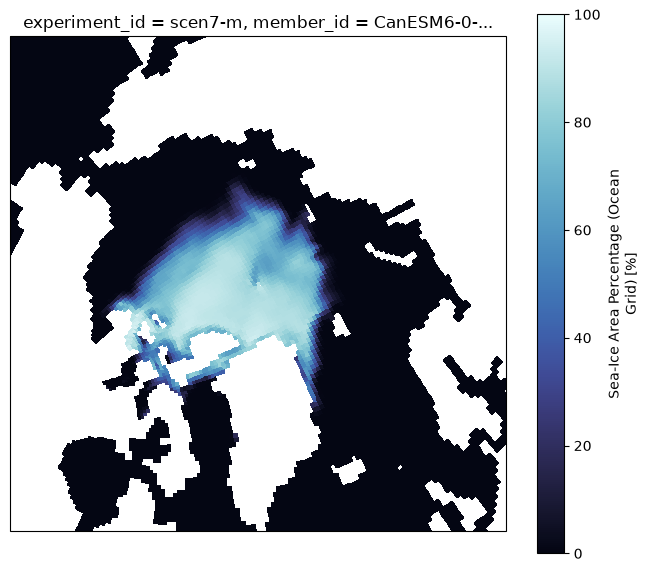

In [12]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.LambertAzimuthalEqualArea(-45, 90)},figsize=(8, 7))

CMIP7_siconc.siconc.sel(time='2026-09').plot(
    ax=ax,
    x="lon", y="lat",               
    transform=ccrs.PlateCarree(),
    cmap=cm.cm.ice, vmin=0, vmax=100,
)

ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())

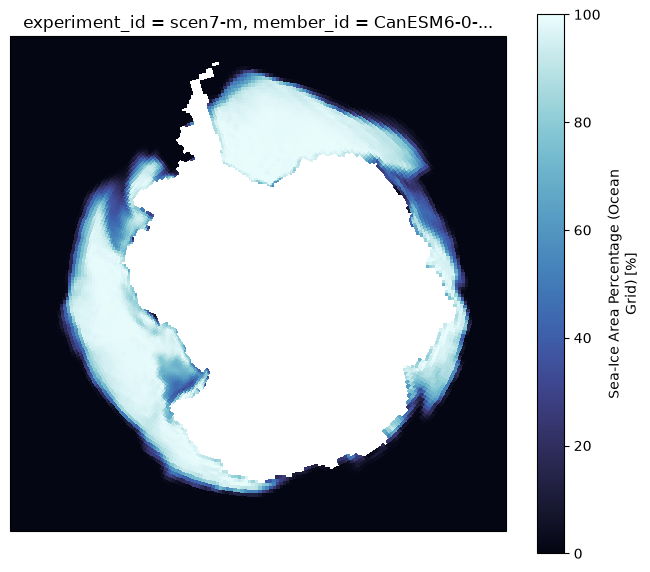

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.LambertAzimuthalEqualArea(-45, -90)},figsize=(8, 7))

CMIP7_siconc.siconc.sel(time='2026-03').where(lambda x:x.lat < 0) .plot(
    ax=ax,
    x="lon", y="lat",               
    transform=ccrs.PlateCarree(),
    cmap=cm.cm.ice, vmin=0, vmax=100,
)

ax.set_extent([-180, 180, -60, -90], ccrs.PlateCarree())
#ax.coastlines()

### Ocean mask and cell area

The ocean mask (`mask`, sftof in %) and cell area (`areacello`, m²) attached by the loader.

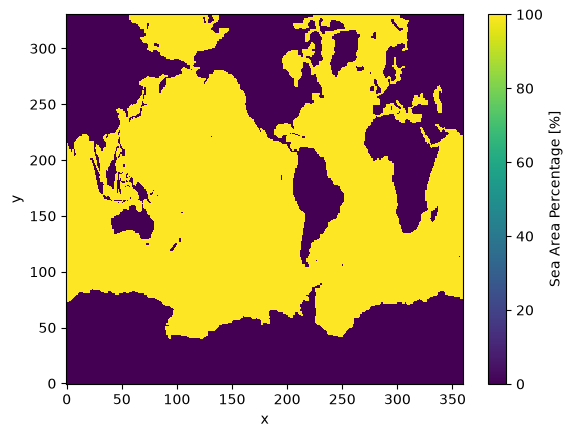

In [14]:
CMIP7_siconc.mask.plot()

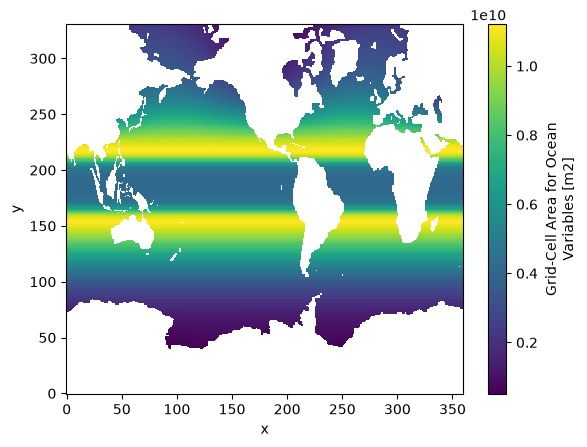

In [15]:
CMIP7_siconc.areacello.plot()

## Clean up

Raw ESGF downloads are kept in `/tmp/esgf_manual`, where space is limited. Set `clear_cache=True` to delete them once you have saved what you need. Datasets loaded before clearing still point at the deleted files, so re-run their load cells before using them again.

In [61]:
clear_cache=False

In [62]:
# Free /tmp space used by the raw ESGF downloads
if clear_cache==True:
    clear_esgf_cache()